In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.outliers_influence as oi
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
pd.set_option("display.max_columns",500)
pd.set_option("display.width",180)
pd.set_option('display.float_format','{:.4f}'.format)
sns.set_theme(style="whitegrid", context="talk")
fact_zone_hour= spark.table("workspace.rapido.fact_zone_hour").toPandas()

In [0]:

TARGET="requests"
if TARGET not in fact_zone_hour.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns sample:{list(fact_zone_hour.columns)[:40]}")
print(f"\n Using FIXED TARGET :{TARGET}")
TEST_SIZE = 0.20
RANDOM_STATE = 42
VIF_CUTOFF = 10
AUTO_DROP_HIGH_VIF = True
VIF_MAX_COLS = 40
MANUAL_FEATURES =[
    "month","day","is_weekend",
    "dow","hour","pre_holiday_flag",
    "post_holiday_flag","is_ramadan",
    "is_ramadan_evening","is_eid","is_peak",
    "holiday_category","event_intensity_city",
    "temp_c","is_rain","rain_mm","traffic_index",
    "available_drivers","avg_trip_km","avg_fare_inr",
    "requests_lag_1","requests_lag_24"
]

categorical_candidates =["holiday_category","holiday_name"]
categorical_cols = [ c for c in categorical_candidates if c not in MANUAL_FEATURES]
base_features = [c for c in MANUAL_FEATURES if c not in categorical_cols]


 Using FIXED TARGET :requests


In [0]:
cols_to_pull = base_features +categorical_cols +[TARGET]
missing_cols = [ c for c in cols_to_pull if c not in fact_zone_hour.columns]
if missing_cols:
    raise ValueError(f"Missing columns:,{missing_cols}")
    
model_df = fact_zone_hour[cols_to_pull].copy()

model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [0]:
bool_cols = model_df.select_dtypes(include=["bool"]).columns.tolist()

if bool_cols:
    print("\n Boolean columns detected:", bool_cols)
    for c in bool_cols:
        model_df[c]= model_df[c].astype(int)

numeric_cols = base_features +[TARGET]
model_df[numeric_cols] = model_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
for c in categorical_cols:
    model_df[c]= model_df[c].astype("string").fillna("unknown")
    
before = len(model_df)
model_df.dropna(subset= numeric_cols, inplace= True)
after = len(model_df)
print(f"\n Dropped rows after numeric coercion :{before- after}(Remaining:{after})")


 Dropped rows after numeric coercion :438600(Remaining:0)



 Dropped rows after final numeric cocion:0(Remaining:0)

 Final feature count: 22
Sample final features: ['month', 'day', 'is_weekend', 'dow', 'hour', 'pre_holiday_flag', 'post_holiday_flag', 'is_ramadan', 'is_ramadan_evening', 'is_eid', 'is_peak', 'holiday_category', 'event_intensity_city', 'temp_c', 'is_rain', 'rain_mm', 'traffic_index', 'available_drivers', 'avg_trip_km', 'avg_fare_inr', 'requests_lag_1', 'requests_lag_24']


/databricks/python/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/databricks/python/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


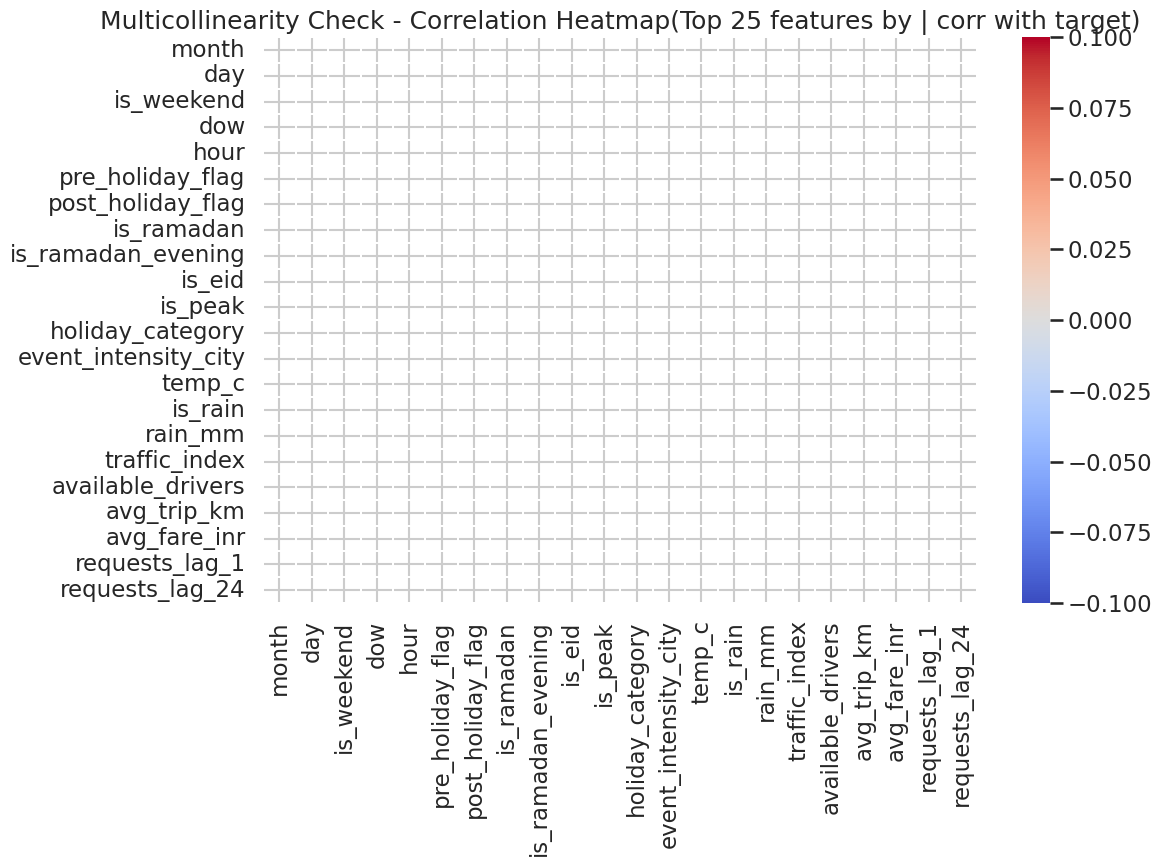

In [0]:
if categorical_cols:
    model_df = pd.get_dummies(model_df, columns= categorical_cols, drop_first=True)

final_features_cols =[c for c in model_df.columns if c !=TARGET]
model_df[final_features_cols +[TARGET]]= model_df[final_features_cols+[TARGET]].apply(pd.to_numeric, errors="coerce")

before2 = len(model_df)
model_df.dropna(subset= final_features_cols +[TARGET], inplace=True)
after2 = len(model_df)
print(f"\n Dropped rows after final numeric cocion:{before2- after2}(Remaining:{after2})")
model_df[final_features_cols +[TARGET]]= model_df[final_features_cols+[TARGET]].astype(float)
print("\n Final feature count:", len(final_features_cols))
print("Sample final features:", final_features_cols[:25])


corr_df = model_df[final_features_cols +[TARGET]].corr(numeric_only= True)
topN = 25
if TARGET in corr_df.columns:
    top_corr=(
        corr_df[TARGET].drop(TARGET, errors="ignore").abs().sort_values(ascending=False).head(topN).index.tolist()
    )
else:
    top_corr = final_features_cols[:topN]
plt.figure(figsize=(12,9))
sns.heatmap(
    model_df[top_corr].corr(numeric_only=True),annot=False,
    cmap="coolwarm",
    linewidth= 0.3
)
plt.title(f"Multicollinearity Check - Correlation Heatmap(Top {topN} features by | corr with target)")
plt.tight_layout()
plt.show()
vif_cols = final_features_cols [:VIF_MAX_COLS]
X_vif = model_df[vif_cols].copy().astype(float)
X_vif_const = sm.add_constant(X_vif)
vif_data=[]
for i in range(X_vif_const.shape[1]):
    col_name = X_vif_const.columns[i]
    vif_val = variance_inflation_factor(X_vif_const.values, i)
    vif_data.append((col_name, vif_val))

vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"]).sort_values("VIF", ascending= False)

print("\n===========================VIF TABLE(Limited Columns)=================")
display(vif_df.round(3))
plt.figure(figsize=(12,5))
plt.bar(vif_df["feature"], vif_df["VIF"])
plt.xticks(rotation=60, ha="right")
plt.axline(5, linestyle="--")
plt.axhline(VIF_CUTOFF, linestyle="--")
plt.title(f"VIF by Feature (Limited Set)- CutOff={VIF_CUTOFF}")
plt.ylabel("VIF")
plt.tight_layout()
plt.show()

In [0]:
fact_zone_hour= spark.table("workspace.rapido.fact_zone_hour").toPandas()

In [0]:
reg_features = final_features_cols.copy()

if AUTO_DROP_HIGH_VIF:
    features_iter = reg_features.copy()
    for _ in range(25):
        X_tmp = sm.add_constant(model_df[features_iter])
        tmp_vifs=[]
        for j in range(X_tmp.shape[1]):
            tmp_vifs.append((X_tmp.columns[j], variance_inflation_factor(X_tmp.values,j)))

        tmp_vif_df = pd.DataFrame(tmp_vifs, columns=["feature","VIF"]).sort_values("VIF", ascending=False)
        tmp_vif_no_const = [tmp_vif_df["feature"]!="const"]
        max_row = tmp_vif_no_const.iloc[0]

        if max_row["VIF"]<= VIF_CUTOFF:
            break

        drop_feature = max_row["feature"]
        print(f"Dropping{drop_feature} due to high VIF:{max_row['VIF']:.2f}")
        features_iter.remove(drop_feature)

        if len(features_iter)<=5:
            print("Stopping: too few features left after VIF pruning.")
            break
    reg_features= features_iter
    print("\n Features after VIF pruning:", reg_features)
else:
    print("\n Auto_DROP_HIGH_VIF = False => Using All final features for regression.")


---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
File <command-7297768185696906>, line 9
      7 tmp_vifs=[]
      8 for j in range(X_tmp.shape[1]):
----> 9     tmp_vifs.append((X_tmp.columns[j], variance_inflation_factor(X_tmp.values,j)))
     11 tmp_vif_df = pd.DataFrame(tmp_vifs, columns=["feature","VIF"]).sort_values("VIF", ascending=False)
     12 tmp_vif_no_const = [tmp_vif_df["feature"]!="const"]

File /databricks/python/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:196, in variance_inflation_factor(exog, exog_idx)
    194 mask = np.arange(k_vars) != exog_idx
    195 x_noti = exog[:, mask]
--> 196 r_squared_i = OLS(x_i, x_noti).fit().rsquared
    197 vif = 1. / (1. - r_squared_i)
    198 return vif

File /databricks/python/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:921, in OLS.__init__(self, endog, exog, missing, hasconst, **kwarg

In [0]:
X=  model_df[reg_features]

Rows: 438600
Columns: 36

Sample columns: ['ts_hour', 'date', 'zone_id', 'zone_name', 'year', 'month', 'day', 'dow', 'hour', 'is_weekend', 'is_holiday', 'is_general_holiday', 'holiday_name', 'holiday_category', 'pre_holiday_flag', 'post_holiday_flag', 'is_ramadan', 'is_ramadan_evening', 'is_eid', 'temp_c', 'is_rain', 'rain_mm', 'traffic_index', 'event_intensity_city', 'requests', 'available_drivers', 'avg_eta_min', 'surge_multiplier', 'avg_trip_km', 'avg_fare_inr', 'cancel_rate', 'avg_rating', 'requests_lag_1', 'requests_lag_24', 'requests_roll_3']

 Using FIXED TARGET: requests

 Manual numeric features: ['month', 'day', 'is_weekend', 'dow', 'hour', 'pre_holiday_flag', 'post_holiday_flag', 'is_ramadan', 'is_ramadan_evening', 'is_eid', 'is_peak', 'event_intensity_city', 'temp_c', 'is_rain', 'rain_mm', 'traffic_index', 'available_drivers', 'avg_trip_km', 'avg_fare_inr', 'requests_lag_1', 'requests_lag_24']
 Manual categorical features: ['holiday_category']

Dropped rows after numeric co

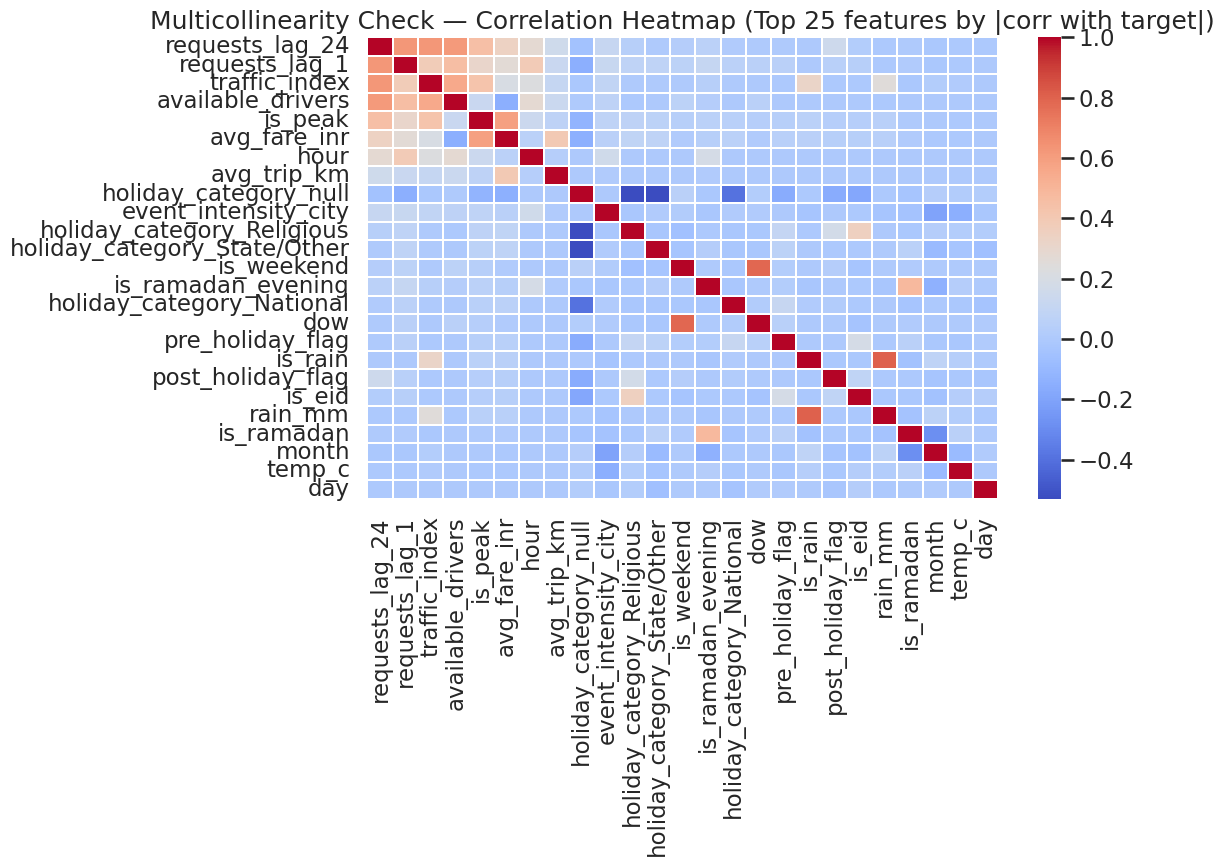


================ VIF TABLE (limited columns) ================


feature,VIF
const,229.816
holiday_category_null,4.079
requests_lag_24,3.341
is_rain,3.141
rain_mm,2.89
avg_fare_inr,2.739
available_drivers,2.736
is_weekend,2.72
dow,2.709
traffic_index,2.441


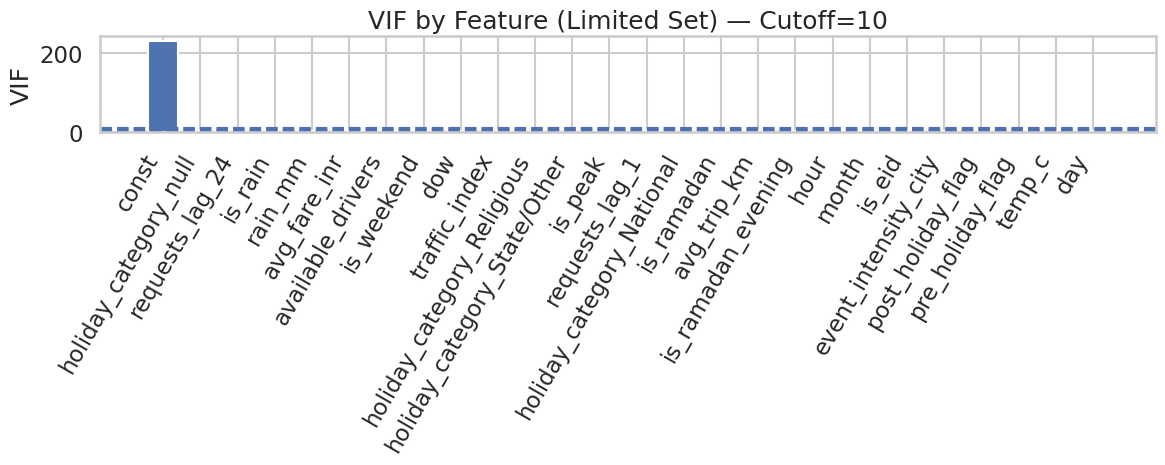


 Features after VIF pruning: ['month', 'day', 'is_weekend', 'dow', 'hour', 'pre_holiday_flag', 'post_holiday_flag', 'is_ramadan', 'is_ramadan_evening', 'is_eid', 'is_peak', 'event_intensity_city', 'temp_c', 'is_rain', 'rain_mm', 'traffic_index', 'available_drivers', 'avg_trip_km', 'avg_fare_inr', 'requests_lag_1', 'requests_lag_24', 'holiday_category_National', 'holiday_category_Religious', 'holiday_category_State/Other', 'holiday_category_null']

================ OLS SUMMARY ================
                            OLS Regression Results                            
Dep. Variable:               requests   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                 9.322e+04
Date:                Fri, 06 Feb 2026   Prob (F-statistic):               0.00
Time:                        04:58:34   Log-Likelihood:            -1.0420e+06
No. Observations:          

Dataset,R2,MAE,MSE,RMSE,MAPE_%
Train,0.869,3.526,22.233,4.715,1.6504473617E8
Test,0.87,3.518,22.01,4.692,2.04528172469E8



================ OLS INFERENCE KPIs ================


Metric,Value
R2 (Train),0.869
Adjusted R2 (Train),0.869
F-statistic,93218.839
F-stat p-value,0.0
AIC,2084083.215
BIC,2084363.188


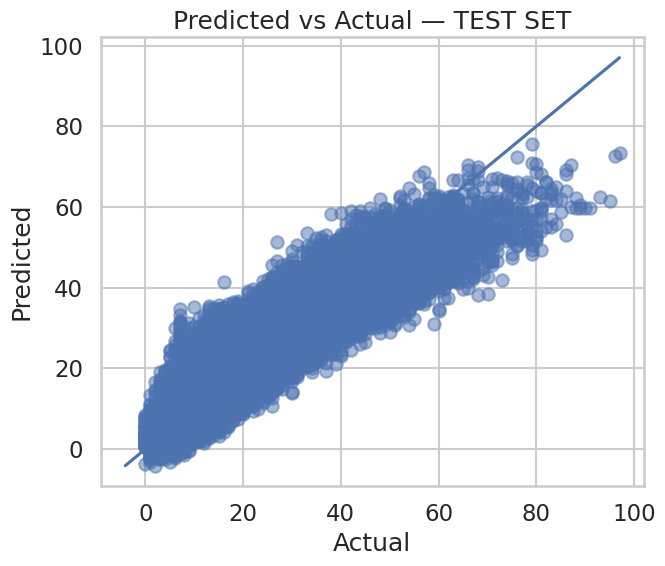

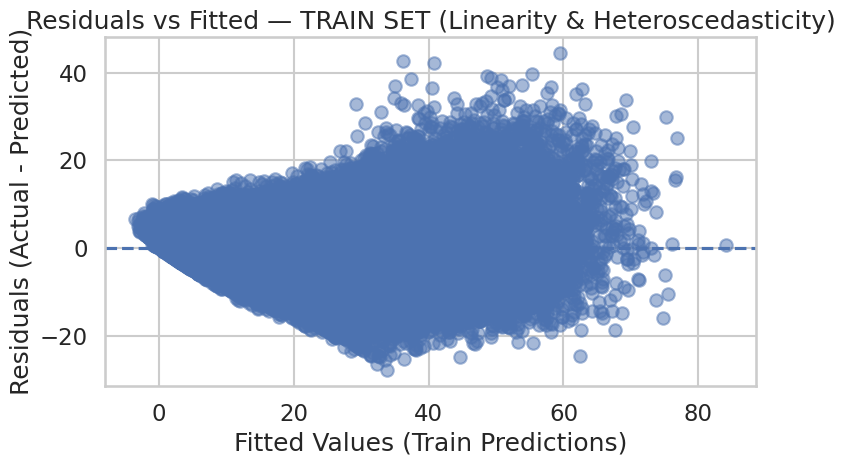

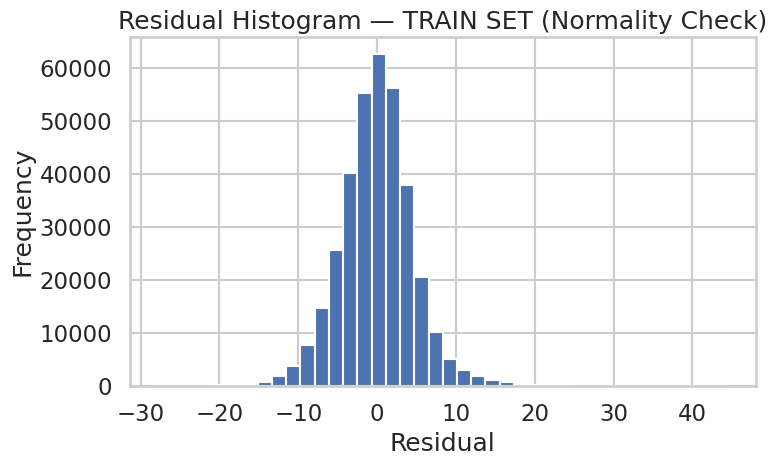

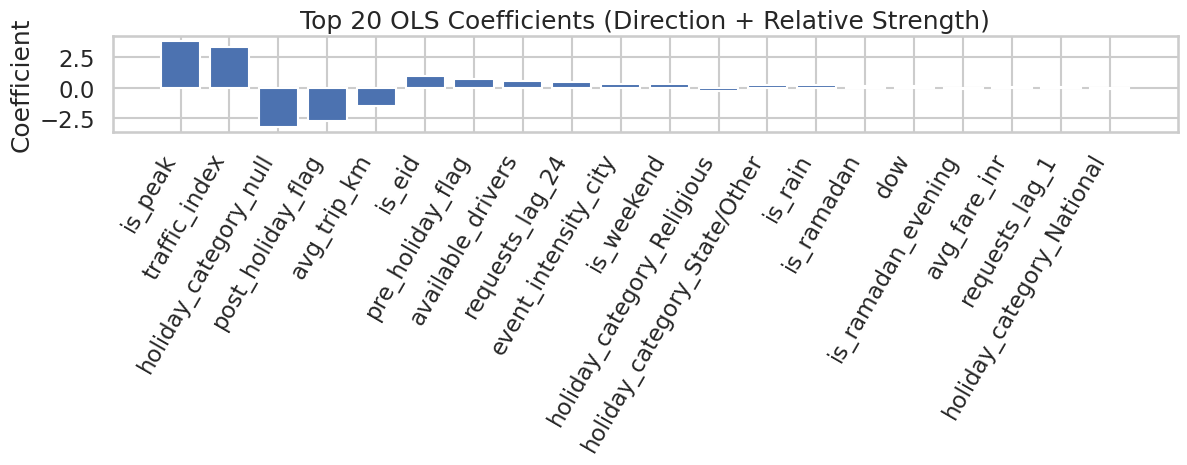

In [0]:
# ============================================================
# RAPIDO — MLR (NO TOGGLES)
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------
# 0) Global Display + Plot Settings
# -----------------------------
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", context="talk")

# ============================================================
# 1) Load Data (Spark -> Pandas)
# ============================================================
fact_zone_hour = spark.table("workspace.rapido.fact_zone_hour").toPandas()

print("Rows:", len(fact_zone_hour))
print("Columns:", fact_zone_hour.shape[1])
print("\nSample columns:", list(fact_zone_hour.columns)[:35])

# ============================================================
# 2) Define Target (y)
# ============================================================
TARGET = "requests"
if TARGET not in fact_zone_hour.columns:
    raise ValueError(f"Target '{TARGET}' not found. Columns sample: {list(fact_zone_hour.columns)[:40]}")
print(f"\n Using FIXED TARGET: {TARGET}")

# ============================================================
# 3) Train/Test + VIF controls (ONLY knobs kept)
# ============================================================
TEST_SIZE = 0.20
RANDOM_STATE = 42

VIF_CUTOFF = 10          # <-- change this threshold as needed
AUTO_DROP_HIGH_VIF = True
VIF_MAX_COLS = 40        # VIF can be expensive; compute on a limited subset for speed

# ============================================================
# 4) Manual Feature Input — RAW hour/dow (NO sin/cos)
# ============================================================
MANUAL_FEATURES = [
    # --- calendar/time ---
    "month", "day", "is_weekend",
    "dow", "hour",
    "pre_holiday_flag", "post_holiday_flag",
    "is_ramadan", "is_ramadan_evening", "is_eid",
    "is_peak",

    # --- holiday representation (pick ONE) ---
    "holiday_category",      # will be one-hot encoded
    # "is_holiday",
    # "is_general_holiday",

    # --- exogenous/context ---
    "event_intensity_city", "temp_c", "is_rain", "rain_mm", "traffic_index",

    # --- supply/ops/experience ---
    "available_drivers", 
    "avg_trip_km", "avg_fare_inr",
    # optional operational outcomes (include only if you WANT them)
    # "avg_eta_min", "cancel_rate", "surge_multiplier",

    # --- lags (include ONLY if you want forecasting-style predictors) ---
    "requests_lag_1", "requests_lag_24",
    # "requests_roll_3",
]

# ============================================================
# 5) Infer handling from MANUAL_FEATURES (automatic)
# ============================================================
categorical_candidates = ["holiday_category", "holiday_name"]
categorical_cols = [c for c in categorical_candidates if c in MANUAL_FEATURES]

# Numeric feature list (categoricals removed; will be expanded via dummies)
base_features = [c for c in MANUAL_FEATURES if c not in categorical_cols]

# Redundancy guardrail: if using holiday_category, do NOT also keep holiday flags
if "holiday_category" in categorical_cols:
    for redundant in ["is_holiday", "is_general_holiday"]:
        if redundant in base_features:
            base_features.remove(redundant)
            print(f" Dropped redundant holiday flag: {redundant}")

print("\n Manual numeric features:", base_features)
print(" Manual categorical features:", categorical_cols)

# ============================================================
# 6) Build Modeling DF
# ============================================================
cols_to_pull = base_features + categorical_cols + [TARGET]
missing_cols = [c for c in cols_to_pull if c not in fact_zone_hour.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataframe: {missing_cols}")

model_df = fact_zone_hour[cols_to_pull].copy()

# Replace inf with nan
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Convert bools to int
bool_cols = model_df.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    print("\nBoolean columns detected:", bool_cols)
    for c in bool_cols:
        model_df[c] = model_df[c].astype(int)

# Coerce numeric columns + target
numeric_cols = base_features + [TARGET]
model_df[numeric_cols] = model_df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Handle categoricals
for c in categorical_cols:
    model_df[c] = model_df[c].astype("string").fillna("Unknown")

# Drop NA rows after coercion
before = len(model_df)
model_df.dropna(subset=numeric_cols, inplace=True)
after = len(model_df)
print(f"\nDropped rows after numeric coercion: {before - after} (Remaining: {after})")

# ============================================================
# 7) One-hot encode categoricals
# ============================================================
if categorical_cols:
    model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

# ============================================================
# 7A) HARD NUMERIC ENFORCEMENT (prevents np.isfinite TypeError)
# ============================================================
final_feature_cols = [c for c in model_df.columns if c != TARGET]

model_df[final_feature_cols + [TARGET]] = model_df[final_feature_cols + [TARGET]].apply(
    pd.to_numeric, errors="coerce"
)

before2 = len(model_df)
model_df.dropna(subset=final_feature_cols + [TARGET], inplace=True)
after2 = len(model_df)
print(f"\nDropped rows after final numeric coercion: {before2 - after2} (Remaining: {after2})")

model_df[final_feature_cols + [TARGET]] = model_df[final_feature_cols + [TARGET]].astype(float)

print("\nFinal feature count:", len(final_feature_cols))
print("Sample final features:", final_feature_cols[:25])

# ============================================================
# 8) MULTICOLLINEARITY — Correlation Heatmap (Top correlated only)
# ============================================================
corr_df = model_df[final_feature_cols + [TARGET]].corr(numeric_only=True)

topN = 25
if TARGET in corr_df.columns:
    top_corr = (
        corr_df[TARGET]
        .drop(TARGET, errors="ignore")
        .abs()
        .sort_values(ascending=False)
        .head(topN)
        .index
        .tolist()
    )
else:
    top_corr = final_feature_cols[:topN]

plt.figure(figsize=(12, 9))
sns.heatmap(
    model_df[top_corr].corr(numeric_only=True),
    annot=False,
    cmap="coolwarm",
    linewidths=0.3
)
plt.title(f"Multicollinearity Check — Correlation Heatmap (Top {topN} features by |corr with target|)")
plt.tight_layout()
plt.show()

# ============================================================
# 9) MULTICOLLINEARITY — VIF (limited columns for speed/readability)
# ============================================================
# If there are many holiday dummies, VIF will naturally be computed on a slice.
vif_cols = final_feature_cols[:VIF_MAX_COLS]

X_vif = model_df[vif_cols].copy().astype(float)
X_vif_const = sm.add_constant(X_vif)

vif_data = []
for i in range(X_vif_const.shape[1]):
    col_name = X_vif_const.columns[i]
    vif_val = variance_inflation_factor(X_vif_const.values, i)
    vif_data.append((col_name, vif_val))

vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)

print("\n================ VIF TABLE (limited columns) ================")
display(vif_df.round(3))

plt.figure(figsize=(12, 5))
plt.bar(vif_df["feature"], vif_df["VIF"])
plt.xticks(rotation=60, ha="right")
plt.axhline(5, linestyle="--")
plt.axhline(VIF_CUTOFF, linestyle="--")
plt.title(f"VIF by Feature (Limited Set) — Cutoff={VIF_CUTOFF}")
plt.ylabel("VIF")
plt.tight_layout()
plt.show()

# ============================================================
# 10) Optional: Auto drop high VIF features (controlled by cutoff)
# ============================================================
reg_features = final_feature_cols.copy()

if AUTO_DROP_HIGH_VIF:
    features_iter = reg_features.copy()
    for _ in range(25):  # cap iterations
        X_tmp = sm.add_constant(model_df[features_iter])
        tmp_vifs = []
        for j in range(X_tmp.shape[1]):
            tmp_vifs.append((X_tmp.columns[j], variance_inflation_factor(X_tmp.values, j)))

        tmp_vif_df = pd.DataFrame(tmp_vifs, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
        tmp_vif_no_const = tmp_vif_df[tmp_vif_df["feature"] != "const"]
        max_row = tmp_vif_no_const.iloc[0]

        if max_row["VIF"] <= VIF_CUTOFF:
            break

        drop_feature = max_row["feature"]
        print(f"Dropping {drop_feature} due to high VIF: {max_row['VIF']:.2f}")
        features_iter.remove(drop_feature)

        if len(features_iter) <= 5:
            print("Stopping: too few features left after VIF pruning.")
            break

    reg_features = features_iter
    print("\n Features after VIF pruning:", reg_features)
else:
    print("\nAUTO_DROP_HIGH_VIF=False => Using all final features for regression.")

# ============================================================
# 11) Train/Test Split
# ============================================================
X = model_df[reg_features].copy().astype(float)
y = model_df[TARGET].copy().astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

# ============================================================
# 12) OLS Regression
# ============================================================
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print("\n================ OLS SUMMARY ================")
print(ols_model.summary())

# ============================================================
# 13) Model Performance KPIs — TRAIN vs TEST
# ============================================================
y_train_pred = ols_model.predict(X_train_sm)
y_test_pred = ols_model.predict(X_test_sm)

def safe_mape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

kpi_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "R2": [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)],
    "MAE": [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)],
    "MSE": [mean_squared_error(y_train, y_train_pred), mean_squared_error(y_test, y_test_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_train, y_train_pred)), np.sqrt(mean_squared_error(y_test, y_test_pred))],
    "MAPE_%": [safe_mape(y_train, y_train_pred), safe_mape(y_test, y_test_pred)]
})

print("\n================ MODEL PERFORMANCE KPIs (TRAIN vs TEST) ================")
display(kpi_df.round(3))

# ============================================================
# 13A) OLS Inference KPIs
# ============================================================
ols_inference_df = pd.DataFrame({
    "Metric": ["R2 (Train)", "Adjusted R2 (Train)", "F-statistic", "F-stat p-value", "AIC", "BIC"],
    "Value": [ols_model.rsquared, ols_model.rsquared_adj, ols_model.fvalue, ols_model.f_pvalue, ols_model.aic, ols_model.bic]
})

print("\n================ OLS INFERENCE KPIs ================")
display(ols_inference_df.round(3))

# ============================================================
# 14) Post-Regression Charts
# ============================================================

# 14A) Predicted vs Actual (TEST)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual — TEST SET")

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.tight_layout()
plt.show()

# 14B) Residuals vs Fitted (TRAIN)
train_residuals = y_train - y_train_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_train_pred, train_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values (Train Predictions)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Fitted — TRAIN SET (Linearity & Heteroscedasticity)")
plt.tight_layout()
plt.show()

# 14C) Residual Histogram (TRAIN)
plt.figure(figsize=(8, 5))
plt.hist(train_residuals, bins=40)
plt.title("Residual Histogram — TRAIN SET (Normality Check)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 14D) Coefficient Plot (Top 20)
coef_series = ols_model.params.drop("const", errors="ignore").copy()
topk = 20
coef_top = coef_series.reindex(coef_series.abs().sort_values(ascending=False).head(topk).index)

plt.figure(figsize=(12, 5))
plt.bar(coef_top.index, coef_top.values)
plt.xticks(rotation=60, ha="right")
plt.title(f"Top {topk} OLS Coefficients (Direction + Relative Strength)")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

# ============================================================
# END
# ============================================================


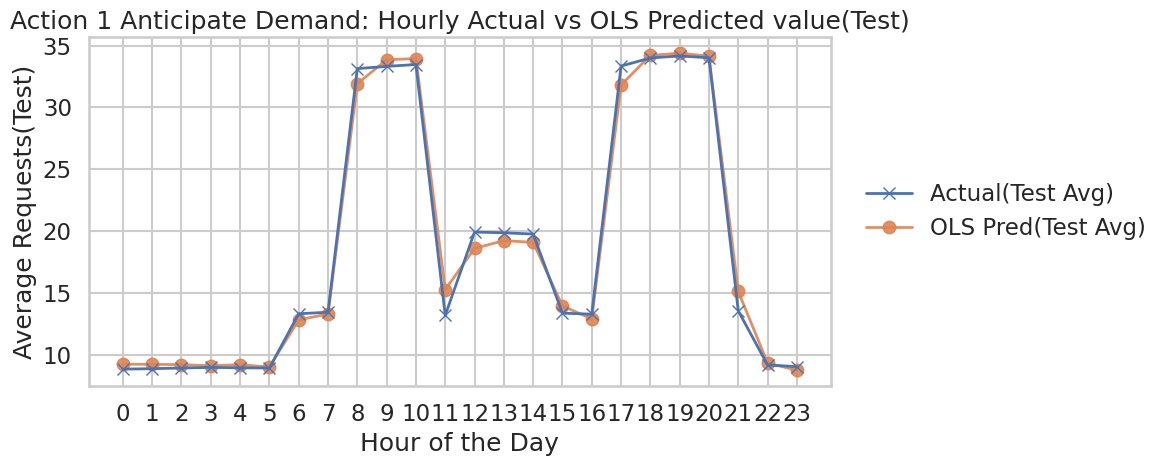

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET ="requests"
HOUR_COL = "hour"
RAIN_COL= "rain_mm"
EVENT_COL ="event_intensity_city"
TRAFFIC_COL="traffic_index"
SUPPLY_COL="available_drivers"

#1)OLS PREDICTIONS
y_test_pred_ols = y_test_pred 

def legend_outside(ax, title=None):
    ax.legend(
        title= title,
        loc="center left",
        bbox_to_anchor=(1.02,0.5),
        frameon=False
    )

# ACTION 1- Anticipate demand(OLS Baseline)
# HOURLY ACTUAL VS PREDICTED(OLS)- TEST set

df_test = X_test.copy()
df_test[TARGET] = y_test
df_test["pred_cols"] = pd.Series(y_test_pred_ols, index= X_test.index)

hourly_pred = (
    df_test.groupby(HOUR_COL)[[TARGET, "pred_cols"]].mean().reset_index().sort_values(HOUR_COL)
)

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(
    hourly_pred[HOUR_COL],
    hourly_pred[TARGET],
    marker="x",
    markersize=8,
    linewidth=2,
    label="Actual(Test Avg)",
    zorder=3
)

ax.plot(
    hourly_pred[HOUR_COL],
    hourly_pred["pred_cols"],
    marker="o",
    linewidth=2,
    alpha=0.9,
    label="OLS Pred(Test Avg)"
)

ax.set_xticks(range(0,24,1))
ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Average Requests(Test)")
ax.set_title("Action 1 Anticipate Demand: Hourly Actual vs OLS Predicted value(Test)")

legend_outside(ax)
fig.tight_layout()
plt.show()


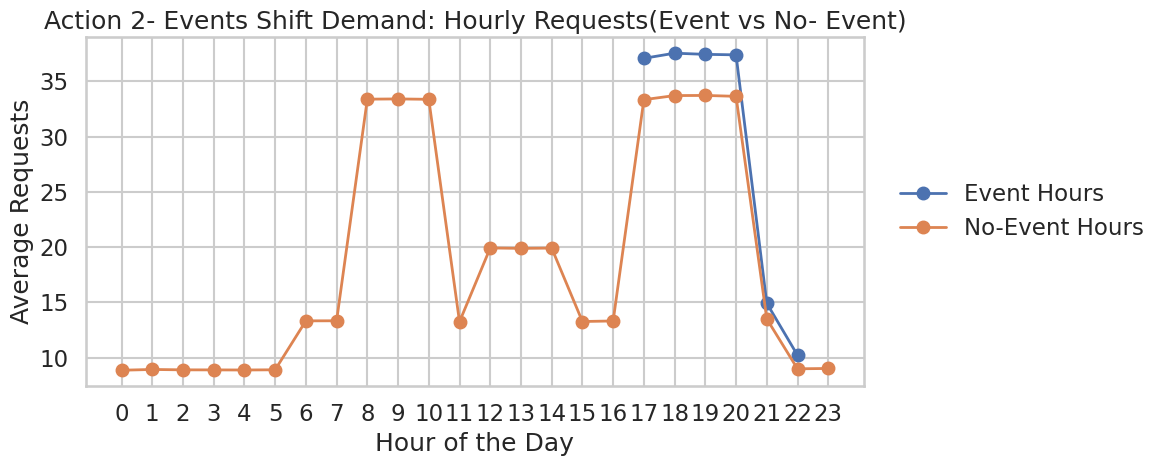

In [0]:
df_events = model_df[[HOUR_COL, EVENT_COL, TARGET]].copy()
df_events["event_flag"]= np.where(df_events[EVENT_COL]>0,"Event Hours","No-Event Hours")

hourly_event=(
    df_events.groupby([HOUR_COL,"event_flag"])[TARGET].mean().reset_index().sort_values(HOUR_COL)
)

hourly_event_pivot=(
    hourly_event.pivot(index=HOUR_COL, columns="event_flag", values=TARGET).reset_index().sort_values(HOUR_COL)
)
fig, ax= plt.subplots(figsize=(12,5))

for col in hourly_event_pivot.columns:
    if col ==HOUR_COL:
        continue
    ax.plot(
        hourly_event_pivot[HOUR_COL],
        hourly_event_pivot[col],
        marker="o",
        linewidth=2,
        label=col
    )

ax.set_xticks(range(0,24,1))
ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Average Requests")
ax.set_title("Action 2- Events Shift Demand: Hourly Requests(Event vs No- Event)")

legend_outside(ax)
fig.tight_layout()
plt.show()

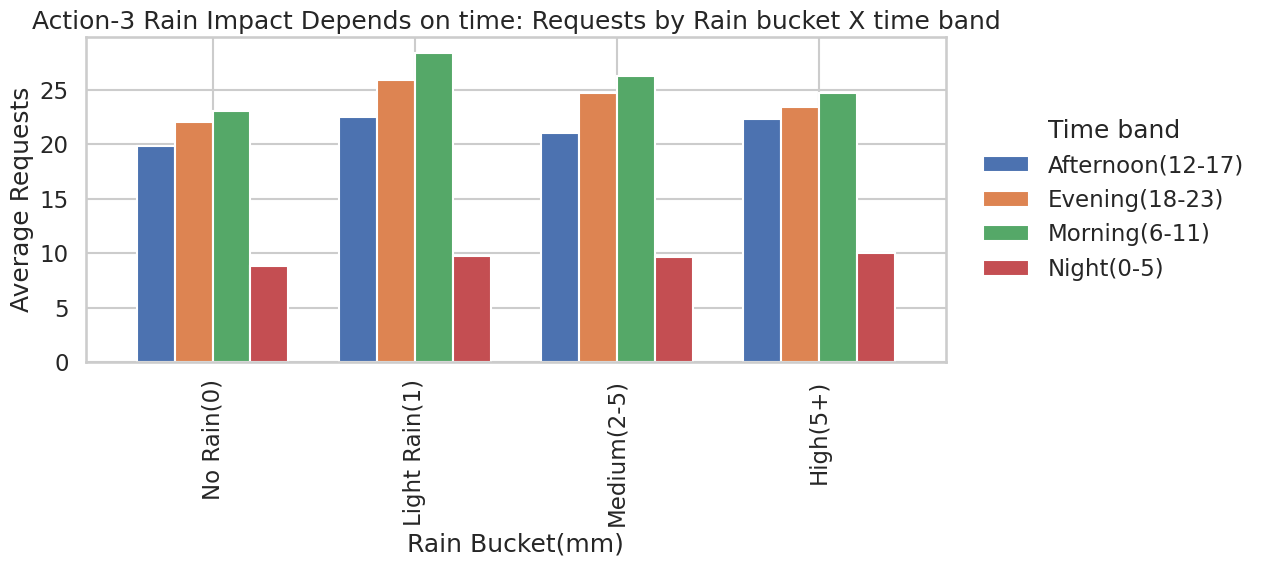

In [0]:
df_rain = model_df[[HOUR_COL, RAIN_COL, TARGET]].copy()

rain_bins = [-np.inf, 0, 2, 5, np.inf]
rain_labels=["No Rain(0)", "Light Rain(1)", "Medium(2-5)","High(5+)"]
df_rain["rain_bucket"]=pd.cut(df_rain[RAIN_COL], bins= rain_bins, labels=rain_labels)

def time_band(h):
    h=int(h)
    if 6<= h <=11:
        return "Morning(6-11)"
    elif 12<= h<=17:
        return "Afternoon(12-17)"
    elif 18<= h<=23:
        return "Evening(18-23)"
    else:
        return "Night(0-5)"
    
df_rain["time_band"]=df_rain[HOUR_COL].apply(time_band)

rain_band =(
    df_rain.groupby(["rain_bucket","time_band"])[TARGET].mean().reset_index()
)

rain_pivot=(
    rain_band.pivot(index="rain_bucket", columns="time_band", values=TARGET).reindex(rain_labels)
)
fig, ax= plt.subplots(figsize=(13,6))
rain_pivot.plot(kind="bar",ax=ax, width=0.75)
ax.set_xlabel("Rain Bucket(mm)")
ax.set_ylabel("Average Requests")
ax.set_title("Action-3 Rain Impact Depends on time: Requests by Rain bucket X time band")
legend_outside(ax, title="Time band")
fig.tight_layout()
plt.show()

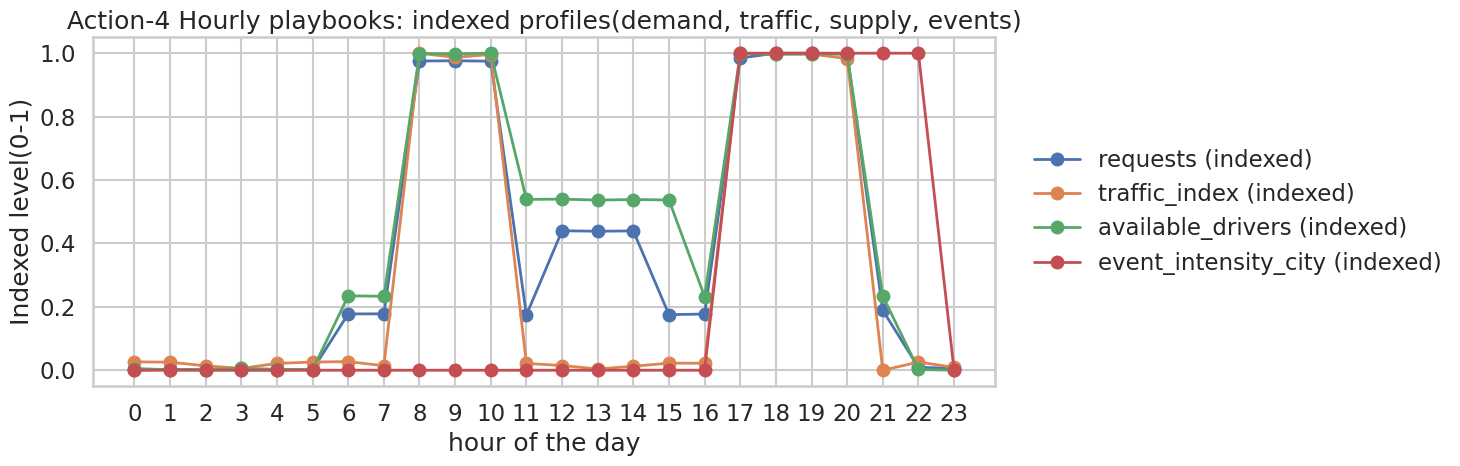

In [0]:
metrics =[TARGET, TRAFFIC_COL, SUPPLY_COL, EVENT_COL]
df_profile = model_df[[HOUR_COL]+metrics].copy()
hourly_profile=(
    df_profile.groupby(HOUR_COL)[metrics].mean().reset_index().sort_values(HOUR_COL)
)
hourly_profile_norm = hourly_profile.copy()
for m in metrics:
    mn, mx= hourly_profile_norm[m].min(), hourly_profile_norm[m].max()
    hourly_profile_norm[m]= (hourly_profile_norm[m]- mn)/ (mx-mn +1e-9)

fig, ax= plt.subplots(figsize=(15,5))
for m in metrics:
    ax.plot(
        hourly_profile_norm[HOUR_COL],
        hourly_profile_norm[m],
        marker="o",
        linewidth=2,
        label=f"{m} (indexed)"
    )
ax.set_xticks(range(0,24,1))
ax.set_xlabel("hour of the day")
ax.set_ylabel("Indexed level(0-1)")
ax.set_title("Action-4 Hourly playbooks: indexed profiles(demand, traffic, supply, events)")
legend_outside(ax)
fig.tight_layout()
plt.show()